# Rob Mulla Channel - Audio Data Processing in Python

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

from glob import glob

import librosa
import librosa.display
import IPython.display as ipd

from itertools import cycle

sns.set_theme(style = 'white', palette=None)
color_pal = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_cycle = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

In [17]:
audio_files = glob('../datasets/ravdess_emotional_speech_data/*/*.wav')

In [19]:
# play audio file
ipd.Audio(audio_files[0])

In [21]:
y, sr = librosa.load(audio_files[0])
print(f'y: {y}, sr: {sr}')

C:\Users\koyel\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


y: [ 5.3765390e-08 -2.1233145e-08 -6.0478342e-09 ...  4.8083174e-14
 -9.6233243e-15  2.8714739e-14], sr: 22050


In [23]:
print(f'Shape of y: {y.shape}')

Shape of y: (72838,)


<Axes: title={'center': 'Raw Audio Sample'}>

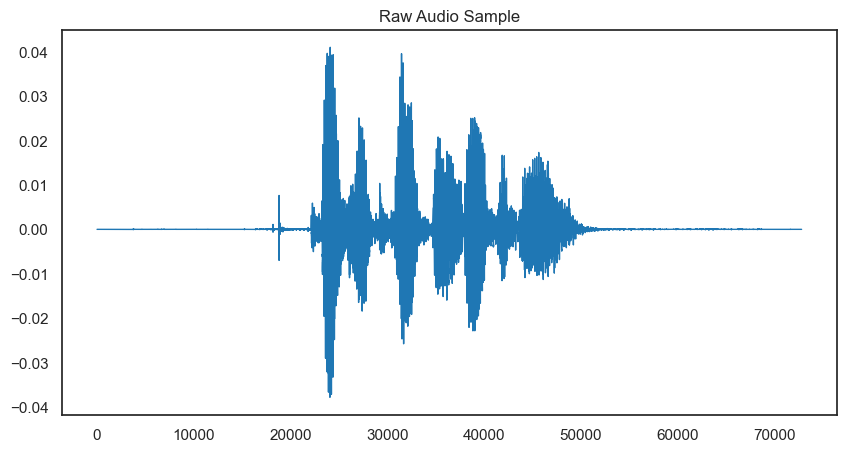

In [33]:
pd.Series(y).plot(
    figsize= (10, 5), 
    lw = 1, 
    title = 'Raw Audio Sample', 
    color = color_pal[0]
)

<Axes: title={'center': 'Raw Audio Trimmed Sample'}>

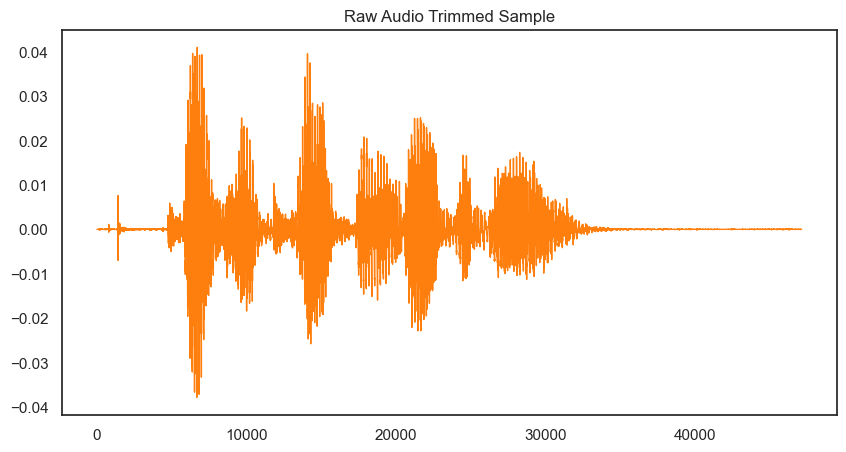

In [35]:
y_trimmed, _ = librosa.effects.trim(y)
pd.Series(y_trimmed).plot(
    figsize= (10, 5), 
    lw = 1, 
    title = 'Raw Audio Trimmed Sample', 
    color = color_pal[1]
)

<Axes: title={'center': 'Raw Audio Trimmed Sample'}>

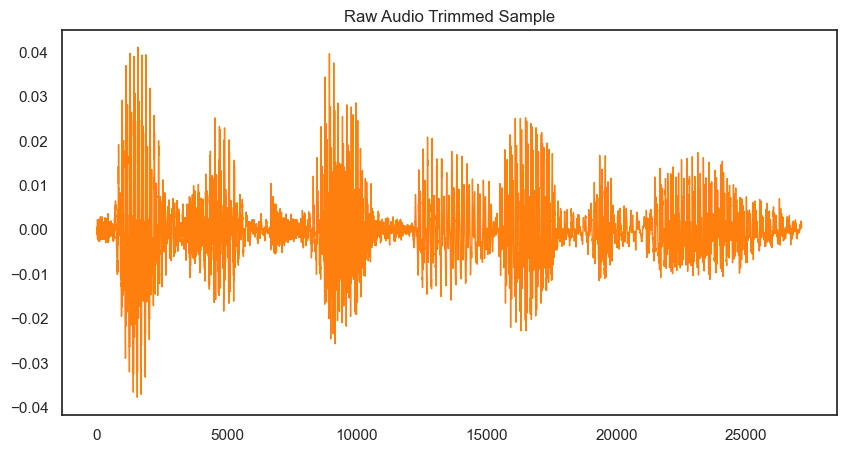

In [37]:
y_trimmed, _ = librosa.effects.trim(y, top_db =20)
pd.Series(y_trimmed).plot(
    figsize= (10, 5), 
    lw = 1, 
    title = 'Raw Audio Trimmed Sample', 
    color = color_pal[1]
)

<Axes: title={'center': 'Raw Audio Trimmed Sample'}>

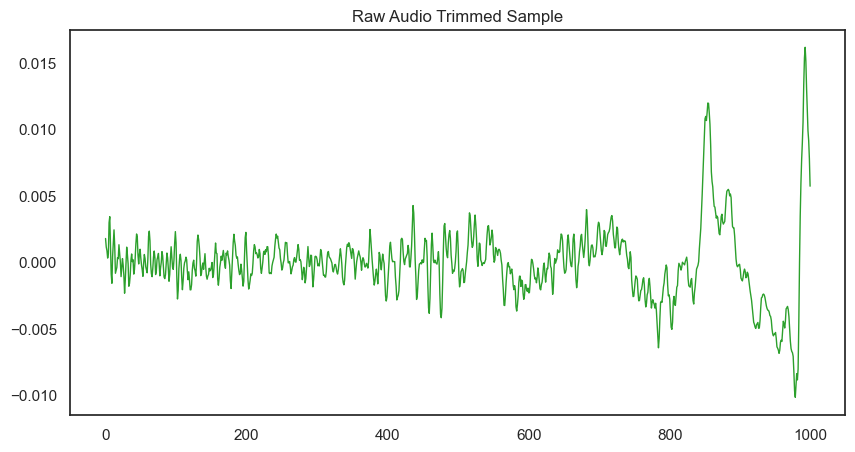

In [39]:
pd.Series(y[30000: 31000]).plot(
    figsize= (10, 5), 
    lw = 1, 
    title = 'Raw Audio Trimmed Sample', 
    color = color_pal[2]
)

<Axes: title={'center': 'Raw Audio Trimmed Sample'}>

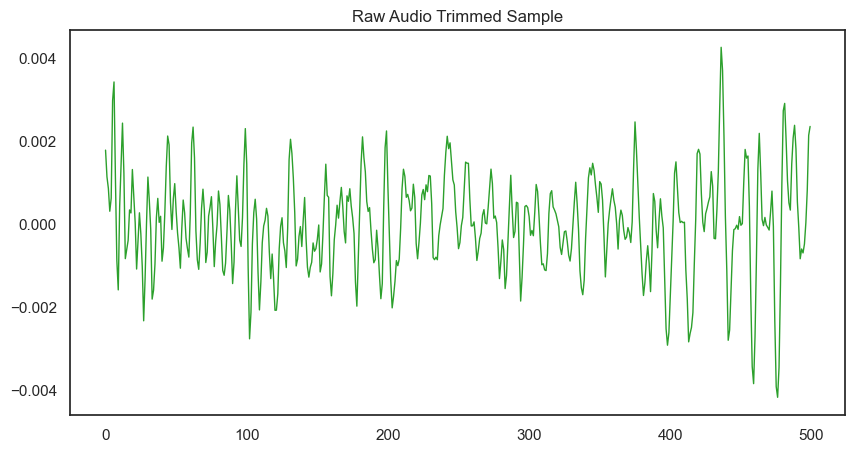

In [41]:
pd.Series(y[30000: 30500]).plot(
    figsize= (10, 5), 
    lw = 1, 
    title = 'Raw Audio Trimmed Sample', 
    color = color_pal[2]
)

In [45]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
S_db.shape

(1025, 143)

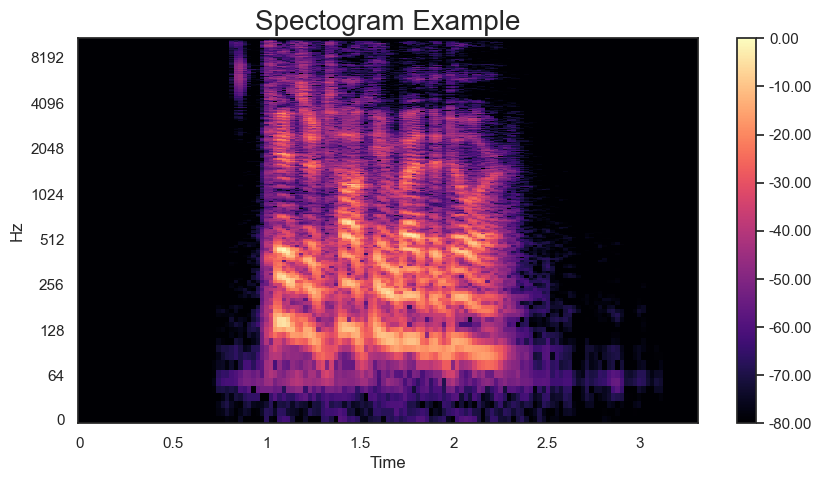

In [53]:
# plot transformed audio
fig, ax = plt.subplots(figsize=(10, 5))
img = librosa.display.specshow(S_db, x_axis='time', y_axis='log', ax = ax)
ax.set_title('Spectogram Example', fontsize=20)
fig.colorbar(img, ax=ax, format=f'%0.2f')

In [61]:
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_db_mel = librosa.amplitude_to_db(np.abs(S), ref=np.max)
S_db_mel.shape

(128, 143)

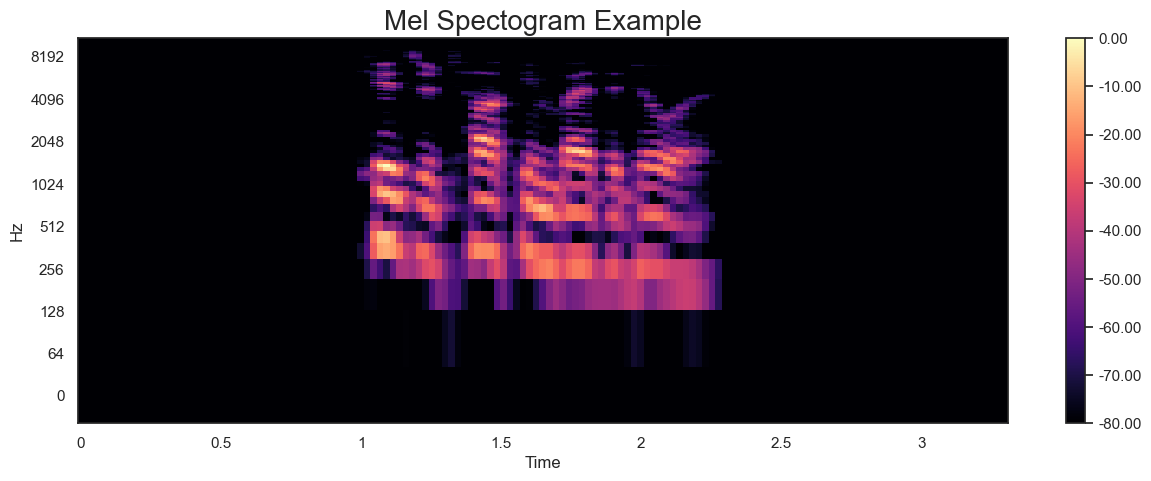

In [65]:
# plot transformed audio
fig, ax = plt.subplots(figsize=(15, 5))
img = librosa.display.specshow(S_db_mel, x_axis='time', y_axis='log', ax = ax)
ax.set_title('Mel Spectogram Example', fontsize=20)
fig.colorbar(img, ax=ax, format=f'%0.2f')